In [ ]:
#!pip install tensorflow

In [ ]:
#!pip install pydot

In [ ]:
#!pip install scikeras

<h4 style="color:darkorange;"> 1. Import Libraries </h4>

In [7]:
# Basic libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

# Evaluation library
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

# Deep Learning libraries
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
## Updated wrapper
from scikeras.wrappers import KerasClassifier

<h4 style="color:darkorange;"> 2. Import Dataset </h4>

In [8]:
# Digit MNIST dataset
(X_train_digit, y_train_digit), (X_test_digit, y_test_digit) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


<h4 style="color:darkorange;"> 3. Checking the data </h4>

In [11]:
# Checking the 2nd image from the training dataset
X_train_digit[1]

# X_train_digit[1] selects the 2nd image from the dataset (in 3D arrays, indexing --> [] means position, not column)
# Column selection happens in 2D data like X[:, 1], where ':' = all rows and '1' = 2nd column

# This is one image (digit) shown as numbers --> Computer’s way of seeing an image (numbers instead of picture)
# It is a 28 × 28 grid, Each number = brightness of a pixel

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [10]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

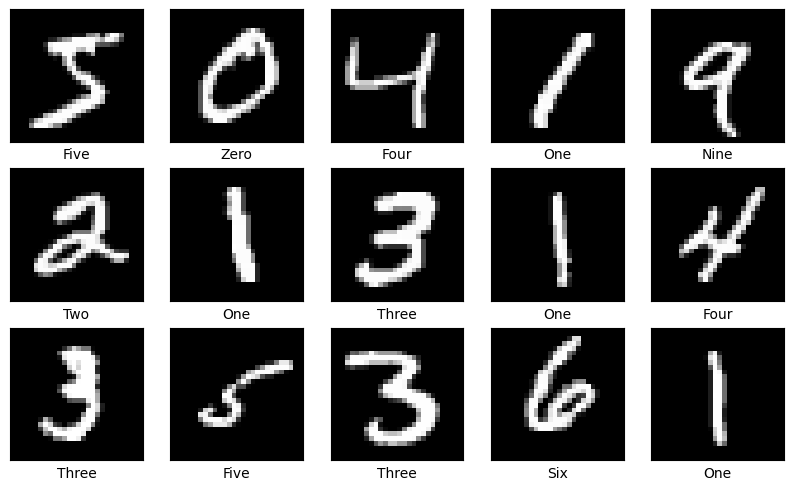

In [12]:
# Names of the numbers in the dataset in order
col_names = ['Zero', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Nine']

# Visualizing the digits
plt.figure(figsize=(10, 10))

for i in range(15):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_digit[i], cmap='gray')
    plt.xlabel(col_names[y_train_digit[i]])

plt.show()

<h4 style="color:darkorange;"> 4. Data Preprocessing </h4>

<h5 style="color:red;"> Checking & Working on Inputs (Preprocessing for ANN model) </h5>

In [13]:
# shape gives --> (number_of_images, height, width)
X_train_digit.shape

(60000, 28, 28)

In [14]:
# ANN cannot take 3D directly, it works with 2D data, so higher-dimensional data must be flattened.
# So, here we are converting the image into 2D

X_train_digit = X_train_digit.reshape(60000, 784)
X_test_digit = X_test_digit.reshape(10000, 784)

In [15]:
X_train_digit.shape

(60000, 784)

<h5 style="color:red;"> Checking & Working on Outputs (Preprocessing for ANN model) </h5>

In [16]:
# y_train_digit & y_test_digit contains the labels (answers) for each image

y_test_digit

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [17]:
y_test_digit.shape

(10000,)

In [18]:
# Encoding Digit MNIST lables

y_train_digit = to_categorical(y_train_digit, num_classes=10)

y_test_digit = to_categorical(y_test_digit, num_classes=10)

In [19]:
# Labels are converted using One-Hot Encoding - Each label is converted into a vector of 0s and 1s.
y_train_digit

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [20]:
# y_train_digit[1] gives the encoded label of 2nd image

y_train_digit[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [21]:
y_train_digit.shape

(60000, 10)

<h4 style="color:darkorange;"> 5. Model creation </h4>

<h5 style="color:red;"> 1st part --> Brain creation </h5>

In [26]:
# Creating base neural network
# This code builds an ANN model that takes image as --> Input (pixels) → Hidden layers (learn patterns) → Output (predict digit: 0–9)

# Sequential means layers are added one after another in order
model = keras.Sequential([ 
    # First layer: takes 784 pixel inputs and learns 256 features using ReLU
    layers.Dense(256, activation='relu', input_shape=(784,)),
    
    # Second layer: reduces and refines features to 64 important patterns
    layers.Dense(64, activation='relu'),

    # Third layer: further learns deeper patterns from previous layer
    layers.Dense(64, activation='relu'),

    # Output layer: gives 10 outputs (digits 0–9) with probability-like values
    layers.Dense(10, activation='sigmoid'),
])

In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

<h5 style="color:darkblue;"> 
• model.summary() shows each layer, its output shape, and number of parameters (weights + bias) <br>
• Parameters are the values the ANN learns during training <br> <br>

Parameter formula: <br>
• Param = output_neurons × (input_neurons + 1)  <br>
• +1 is for bias (each neuron has one extra bias value) <br> <br>

• First layer explanation: <br>
Input = 784 pixels, Output = 256 neurons <br> <br>

Param = 256 × (784 + 1) <br>
      = 256 × 785 <br>
      = 200,960 <br> <br>

• Output Shape meaning:  <br>
(None, 256) → 256 outputs for each sample <br>
None → number of samples (can be anything, not fixed) <br> <br>

• Total parameters = sum of all layer parameters <br> <br>

• Trainable vs Non-trainable: <br>
Trainable params → values the model learns (weights + bias) <br>
Non-trainable → fixed values (none here, so 0)</h5>

<h5 style="color:green;"> 

Why do we add bias?<br> 
• Bias is an extra value added to each neuron to improve learning. (y = wx + b)<br> 
• It helps the model shift the output and not depend only on input values.<br> 
• Without bias (y = wx), the model is limited and cannot fit data properly.<br> 
• That’s why we use (input_neurons + 1) in parameter calculation.<br> 
• +1 represents bias for each neuron.<br> <br> 

*** Bias = flexibility → helps model fit data better</h5>

<h5 style="color:red;"> 2nd part --> Compiling </h5>

In [32]:
# Compiling the model
model.compile(loss = "categorical_crossentropy", 
              optimizer = "adam", 
              metrics = ['accuracy'])

<h5 style="color:darkblue;"> 
• compile = tell model how to learn (loss + optimizer + metrics)<br> 
• loss → measures how wrong the prediction is<br> 
• optimizer → updates weights to improve learning (adam is commonly used)<br> 
• metrics → used to evaluate model performance (accuracy here)</h5>

<h5 style="color:red;"> 3rd part --> Fit method </h5>

In [34]:
history = model.fit(X_train_digit, y_train_digit, batch_size=100, epochs=10, validation_data=(X_test_digit, y_test_digit))

# fit() is used to train the model
# batch_size → number of samples processed at once
# epochs → number of times model sees full dataset
# validation_data → used to check performance on unseen data

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7571 - loss: 1.3199 - val_accuracy: 0.8628 - val_loss: 0.3954
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8848 - loss: 0.2771 - val_accuracy: 0.8946 - val_loss: 0.2580
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9064 - loss: 0.1970 - val_accuracy: 0.9018 - val_loss: 0.2224
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9164 - loss: 0.1536 - val_accuracy: 0.9243 - val_loss: 0.2239
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9153 - loss: 0.1389 - val_accuracy: 0.9155 - val_loss: 0.1824
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9143 - loss: 0.1259 - val_accuracy: 0.9068 - val_loss: 0.1897
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9007 - loss: 0.1141 - val_accuracy: 0.8848 - val_loss: 0.1636
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9001 - loss: 0.1044 - val_accuracy: 

<h5 style="color:darkblue;">  
• Model is learning patterns from training data step-by-step (epoch by epoch).<br>
• After each epoch, performance is checked on both training data and validation data.<br><br>

What is happening in each epoch?<br>
• Epoch = one full pass of entire training data<br>
• In each epoch:<br>
1. Model takes input (X_train)<br>
2. Makes prediction<br>
3. Compares with actual output (y_train) using loss<br>
4. Updates weights using optimizer<br>
5. Improves learning step-by-step<br><br>

Understanding each term in output:<br>
• 600/600 → number of batches completed<br>
• accuracy → how many predictions are correct (on training data)<br>
• loss → how wrong the model is (lower is better)<br>
• val_accuracy → accuracy on unseen data (test/validation)<br>
• val_loss → error on unseen data<br><br>

What we observe from this output?<br>
• Accuracy increases from 0.75 → 0.91 → model is learning<br>
• Loss decreases from ~1.31 → 0.08 → errors are reducing<br>
• val_accuracy also improves (0.86 → 0.90) → good generalization<br>
• In this case, final accuracy (val_accuracy) ≈ 0.8775 (87.75%)</h5>

<h5 style="color:green;"> If we want to improve the model performance:
</h5>

In [ ]:
# This model adds Dropout and Batch Normalization to reduce overfitting and improve accuracy

model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(10, activation='sigmoid'),
])

<h5 style="color:darkblue;"> 

• layers.Dropout(0.3) --> Randomly drops 30% neurons → prevents overfitting (model doesn't memorize)<br> 
• layers.BatchNormalization() --> Normalizes data → makes training faster and more stable</h5>

<h4 style="color:darkorange;"> 6. Prediction </h4>

In [35]:
# Predicting the labels - DIGIT
y_predict = model.predict(X_test_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<h5 style="color:darkblue;"> 

• model.predict() gives probability values for each class (0–9)<br> 
• Output is not a single number, but a list of probabilities</h5>

In [36]:
y_predict[0]

array([1.2412241e-02, 9.9999875e-01, 1.0000000e+00, 9.9990064e-01,
       7.6587251e-03, 5.7410514e-01, 7.7168555e-16, 1.0000000e+00,
       1.9317271e-12, 9.9986917e-01], dtype=float32)

<h5 style="color:darkblue;"> 
 
• y_predict[0] shows probabilities for first image<br>
• Highest value represents the predicted digit</h5>

In [38]:
# Convert probabilities → actual digit

# np.argmax() picks index of highest value
# This converts probability vector → predicted class (actual digit)

y_predicts = np.argmax(y_predict, axis=1) # Here we get the index of maximum value in the encoded vector

In [39]:
# predicted output - test set 
y_predicts

array([2, 2, 1, ..., 4, 4, 6], dtype=int64)

<h5 style="color:darkblue;"> 
• y_predicts contains predicted digits for all test images</h5>

In [40]:
# y_test_digit is one-hot encoded
# np.argmax() converts it back to actual digit labels

y_test_digit_eval = np.argmax(y_test_digit, axis=1)

In [41]:
# actual output - test set
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

<h5 style="color:darkblue;"> 
• y_test_digit_eval contains true labels for test data</h5>

<h4 style="color:darkorange;"> 7. Evaluation </h4>

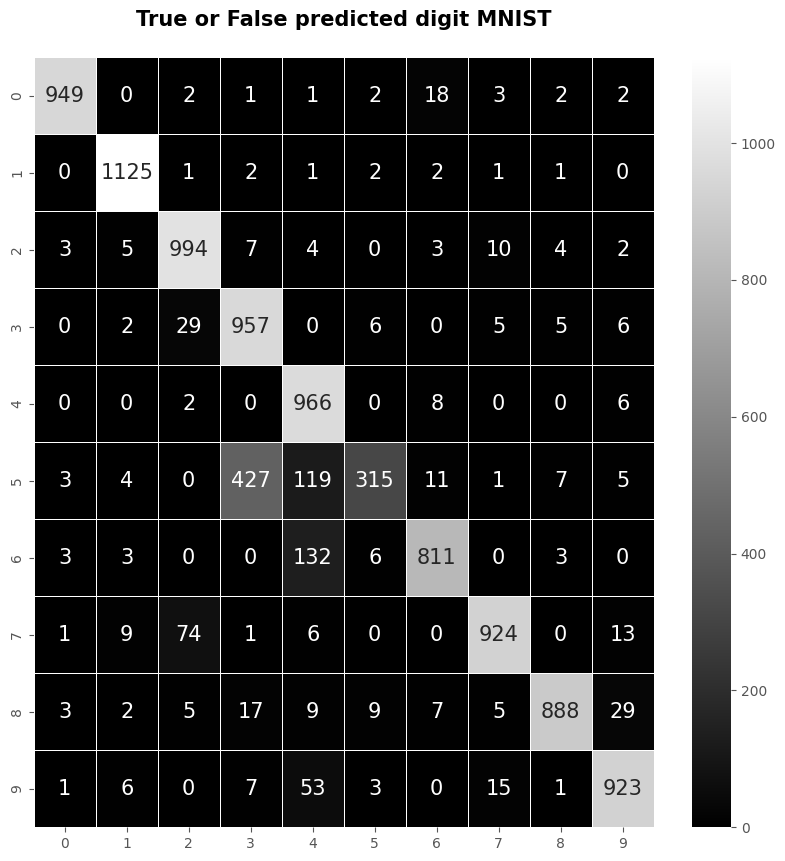

In [45]:
# Confusion matrix for Digit MNIST
con_mat=confusion_matrix(y_test_digit_eval, y_predicts)
plt.style.use('ggplot')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat, annot=True, annot_kws={'size':15}, linewidths=0.5, fmt="d", cmap="gray")
plt.title('True or False predicted digit MNIST\n', fontweight='bold', fontsize=15)
plt.show()

<h5 style="color:darkblue;"> 

• Confusion matrix shows how well the model predicted each digit (0–9)<br> 
• Rows → actual digits (true values), Columns → predicted digits<br> 
• Each cell → how many times prediction happened.<br> 
• Diagonal → correct, Others → errors<br> 
• Example: 949 → digit 0 correctly predicted 949 times</h5>

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test_digit_eval, y_predicts))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       980
           1       0.97      0.99      0.98      1135
           2       0.90      0.96      0.93      1032
           3       0.67      0.95      0.79      1010
           4       0.75      0.98      0.85       982
           5       0.92      0.35      0.51       892
           6       0.94      0.85      0.89       958
           7       0.96      0.90      0.93      1028
           8       0.97      0.91      0.94       974
           9       0.94      0.91      0.93      1009

    accuracy                           0.89     10000
   macro avg       0.90      0.88      0.87     10000
weighted avg       0.90      0.89      0.88     10000



<h5 style="color:darkblue;"> 
• Most digits (0,1,7,8,9) have high scores → good performance<br>
• Digit 5 has very low recall (0.35) → model misses many 5s<br>
• Digit 3 and 4 also slightly weaker compared to others<br>
• This matches confusion matrix → where errors were higher</h5>

In [49]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


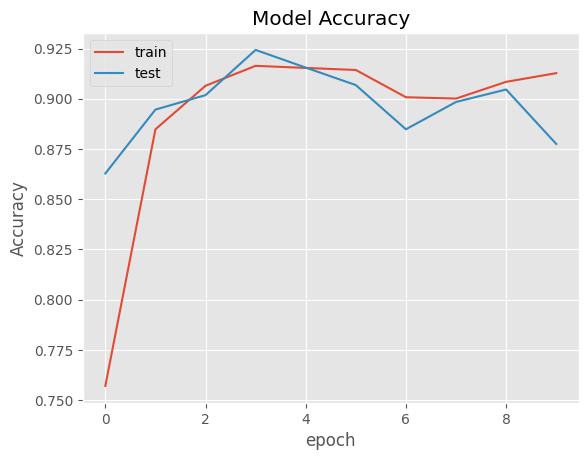

In [48]:
# Summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

<h5 style="color:darkblue;"> 
• This graph shows how model accuracy changes during training (epoch by epoch)<br> 
• Accuracy increases in early epochs → model is learning patterns<br> 
• Training accuracy keeps improving but test accuracy fluctuates<br> 
• Best performance is around epoch 3–5 (peak validation accuracy)<br> 
• After that, model does not improve much → learning stabilizes<br> 
• Training more epochs may not always improve performance</h5>

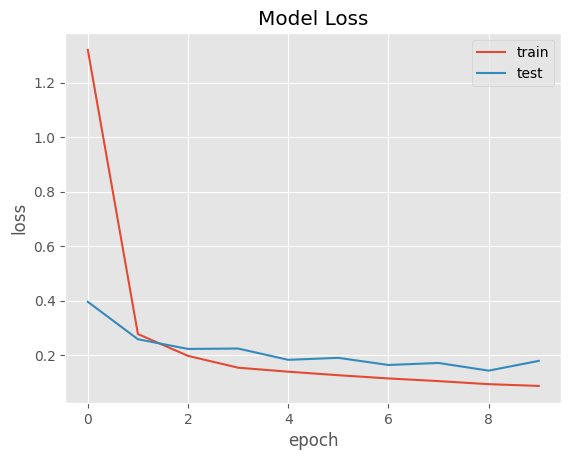

In [50]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

<h5 style="color:darkblue;"> 
 
• This graph shows how model error (loss) decreases during training<br> 
• Low loss = better model performance<br> 
• Loss decreases sharply at start → model is learning fast<br> 
• Training loss keeps decreasing → model improving on training data<br> 
• Validation loss decreases then slightly fluctuates → normal behavior</h5>

<h4 style="color:darkorange;"> 8. Test & display results </h4>

In [52]:
# Predicting a single image (3rd image in dataset --> X_test_digit[[2]])

# tf.expand_dims(X_test_digit[0])
y_predict_single = model.predict(X_test_digit[[2]])

y_predicts_single = np.argmax(y_predict_single, axis=1)  
# Here we get the index of maximum value in the encoded vector

y_test_digit_eval = np.argmax(y_test_digit, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


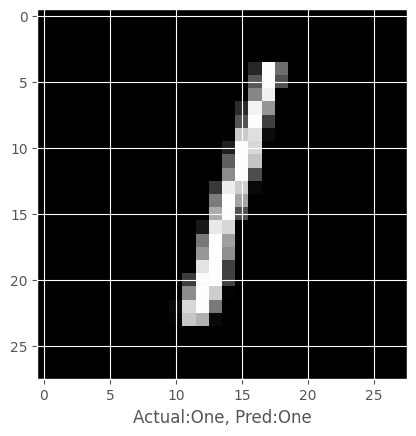

In [53]:
# Names of numbers in the dataset in order
col_names = ['Zero', 'One', 'Two', 'Three', 'Four',
             'Five', 'Six', 'Seven', 'Eight', 'Nine']

# Visualizing the digits
# plt.figure(figsize=(10,10))

plt.imshow(X_test_digit[2].reshape(28,28), cmap='gray')

plt.xlabel('Actual:{}, Pred:{}'.format(
    col_names[np.argmax(y_test_digit[2])],  # [2] → selects the 3rd test image (we are checking prediction for that specific image)
    col_names[y_predicts_single[0]]         # [0] → we take the first (and only) prediction result for that single image
))

plt.show()